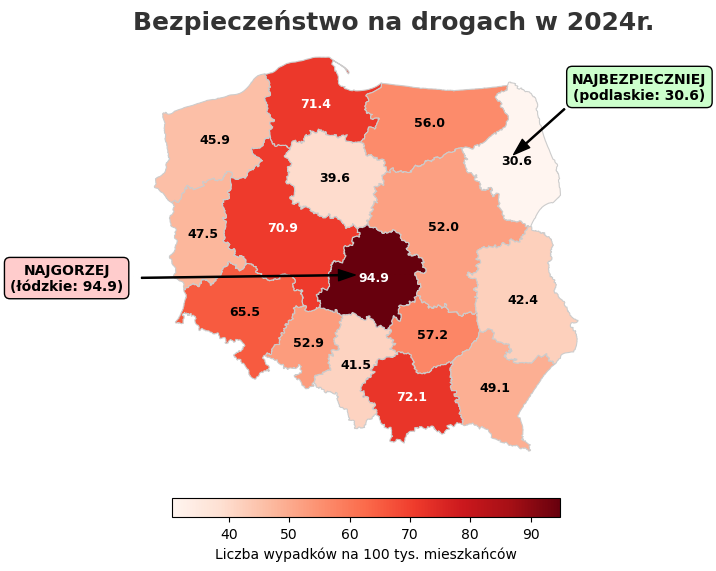

In [1]:
### Źródło danych do wykresów 1,2,3 https://statystyka.policja.pl/st/ruch-drogowy/76562,wypadki-drogowe-raporty-roczne.html


import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


url_do_mapy = "https://raw.githubusercontent.com/ppatrzyk/polska-geojson/master/wojewodztwa/wojewodztwa-min.geojson"
mapa_pl = gpd.read_file(url_do_mapy).to_crs(epsg=2180) 

moje_dane = {
    'wojewodztwo': [
        'śląskie', 'mazowieckie', 'małopolskie', 'wielkopolskie', 
        'dolnośląskie', 'pomorskie', 'łódzkie', 'podkarpackie',
        'lubelskie', 'kujawsko-pomorskie', 'zachodniopomorskie',
        'warmińsko-mazurskie', 'świętokrzyskie', 'podlaskie',
        'lubuskie', 'opolskie'
    ],
    'liczba_wypadkow na 100 000 mieszkańców': [
        41.5, 52, 72.1, 70.9, 
        65.5, 71.4, 94.9, 49.1,
        42.4, 39.6, 45.9,
        56, 57.2, 30.6,
        47.5, 52.9
    ]
}
df_wypadki = pd.DataFrame(moje_dane)
col_name = 'liczba_wypadkow na 100 000 mieszkańców' 

mapa_z_danymi = mapa_pl.merge(df_wypadki, left_on='nazwa', right_on='wojewodztwo')


fig, ax = plt.subplots(1, 1, figsize=(10, 6))

mapa_z_danymi.plot(
    column=col_name,
    cmap='Reds',
    linewidth=0.8,
    edgecolor='0.8', 
    legend=True,
    legend_kwds={
        'label': "Liczba wypadków na 100 tys. mieszkańców", 
        'orientation': "horizontal", 
        'shrink': 0.4, 
        'pad': 0.05,
        'format': "%.0f"
    },
    ax=ax
)


ax.set_title('Bezpieczeństwo na drogach w 2024r.', loc='left', fontdict={'fontsize': 18, 'fontweight': 'bold', 'color': '#333333'})


ax.axis('off')


for idx, row in mapa_z_danymi.iterrows():
    wartosc = row[col_name]
    kolor_tekstu = 'white' if wartosc > 68 else 'black' 
    
    plt.annotate(
        text=f"{wartosc}", 
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center',
        va='center', 
        fontsize=9,
        color=kolor_tekstu, 
        fontweight='bold'   
    )


row_min = mapa_z_danymi.loc[mapa_z_danymi[col_name].idxmin()]
row_max = mapa_z_danymi.loc[mapa_z_danymi[col_name].idxmax()]

def dodaj_strzalke(row, opis, kolor_tla, offset_x, offset_y):
    ax.annotate(
        text=f"{opis}\n({row['wojewodztwo']}: {row[col_name]})",
        xy=(row.geometry.centroid.x -10000, row.geometry.centroid.y + 5000),
        xytext=(row.geometry.centroid.x + offset_x, row.geometry.centroid.y + offset_y),
        arrowprops=dict(color='black', shrink=0.05, width=0.8, headwidth=8),
        bbox=dict(boxstyle="round,pad=0.4", fc=kolor_tla, ec="black", alpha=1.0),
        fontsize=10,
        fontweight='bold',
        ha='center' 
    )

dodaj_strzalke(row_min, "NAJBEZPIECZNIEJ", "#ccffcc", 200000, 100000)
dodaj_strzalke(row_max, "NAJGORZEJ", "#ffcccc", -500000, -20000)


plt.tight_layout()
plt.savefig('BezpieczenstwoNaDrogach.png')
plt.show()

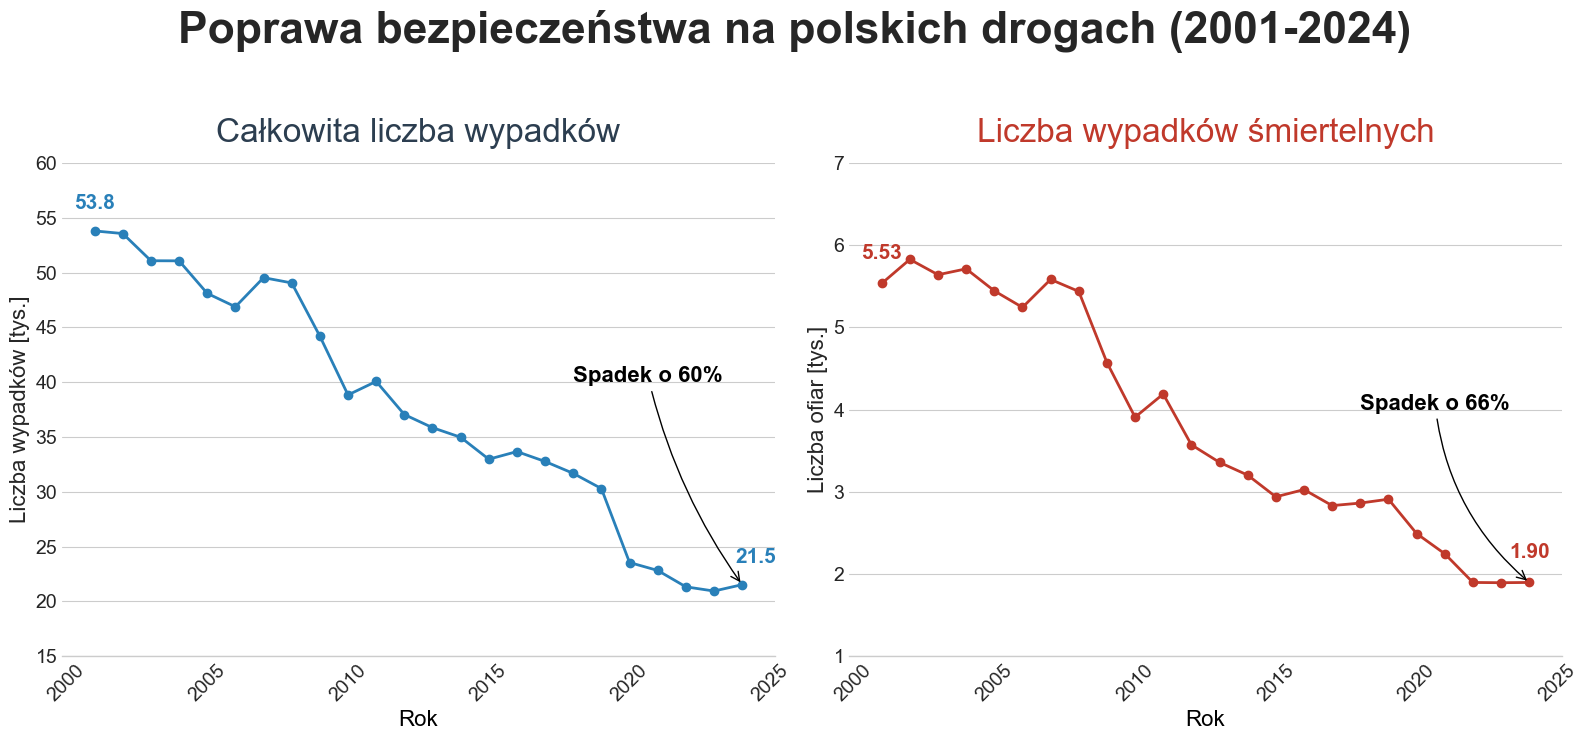

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
rok=[2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024]
l_wypadkow = [53799,53559,51078,51069,48100,46876,49536,49054,44196,38832,40065,37046,35847,34970,32967,33664,32760,31674,30288,
              23540,22816,21322,20936,21519]
l_wypadkow_smiertelnych = [5534,5827,5640,5712,5444,5243,5583,5437,4572,3907,4189,3571,3357,3202,2938,3026,2831,2862,2909,
                           2491,2245,1896,1893,1896]

y1 = [i / 1000 for i in l_wypadkow]
y2 = [i / 1000 for i in l_wypadkow_smiertelnych]


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

fig, axs = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Poprawa bezpieczeństwa na polskich drogach (2001-2024)', fontsize=32, fontweight='bold', y=1.05)


ax1 = axs[0]
ax1.plot(rok, y1, color='#2980b9', linewidth=2, marker='o', markersize=6)


ax1.set_title('Całkowita liczba wypadków', fontsize=24, color='#2c3e50', pad=15)
ax1.set_ylim(15, 60) 
ax1.set_ylabel('Liczba wypadków [tys.]', fontsize=16)
ax1.grid(axis='x', alpha=0)


ax1.text(2001, y1[0] + 2, f'{y1[0]:.1f}', ha='center', color='#2980b9', fontweight='bold',fontsize=15)
ax1.text(2024 + 0.5, y1[-1] + 2, f'{y1[-1]:.1f}', ha='center', color='#2980b9', fontweight='bold',fontsize=15)


spadek_proc1 = ((l_wypadkow[0] - l_wypadkow[-1]) / l_wypadkow[0]) * 100
ax1.annotate(f'Spadek o {spadek_proc1:.0f}%', 
             xy=(2024, y1[-1]),     
             xytext=(2018, 40),    
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=+0.1"),
             fontsize=16, fontweight='bold', color='black')



ax2 = axs[1]
ax2.plot(rok, y2, color='#c0392b', linewidth=2, marker='o', markersize=6)


ax2.set_title('Liczba wypadków śmiertelnych', fontsize=24, color='#c0392b', pad=15)
ax2.set_ylim(1, 7) 
ax2.set_ylabel('Liczba ofiar [tys.]', fontsize=16)
ax2.grid(axis='x', alpha=0)


spadek_proc2 = ((l_wypadkow_smiertelnych[0] - l_wypadkow_smiertelnych[-1]) / l_wypadkow_smiertelnych[0]) * 100
ax2.annotate(f'Spadek o {spadek_proc2:.0f}%', 
             xy=(2024, y2[-1]),    
             xytext=(2018, 4),     
             arrowprops=dict(facecolor='black', arrowstyle='->', connectionstyle="arc3,rad=+0.2"),
             fontsize=16, fontweight='bold', color='black')


ax2.text(2001, y2[0] + 0.3, f'{y2[0]:.2f}', ha='center', color='#c0392b', fontweight='bold',fontsize=15)
ax2.text(2024, y2[-1] + 0.3, f'{y2[-1]:.2f}', ha='center', color='#c0392b', fontweight='bold',fontsize=15)

for ax in axs:
    ax.set_xlabel('Rok', fontsize=16, color='black')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', rotation=45,labelsize=14)
    ax.tick_params(axis='y',labelsize=14)

plt.tight_layout()
plt.savefig('PoprawaBezpieczenstwa.png', bbox_inches='tight', pad_inches=0.1, dpi=300)
plt.show()

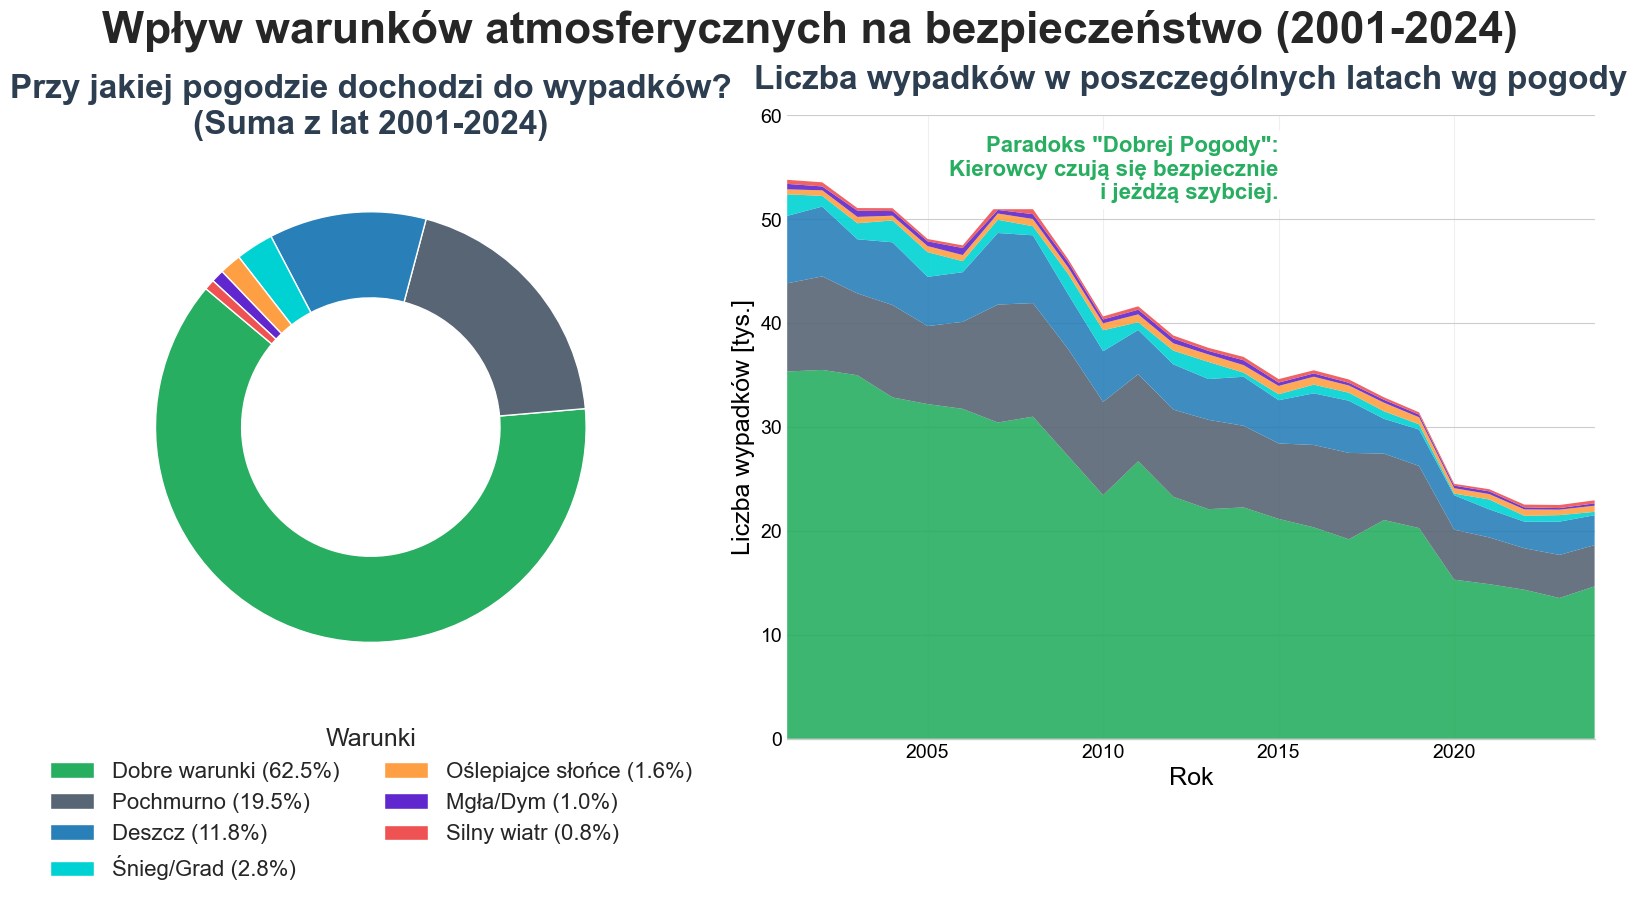

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

dane={
    'Rok' : [2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
    'Dobre warunki' : [35348,35503,34990,32858,32214,31755,30441,31003,27226,23452,26710,23290,22102,22268,21162,20349,19205,21055,20281,15316,14881,14349,13552,14676],
    'Oślepiajce słońce' : [479,536,611,456,586,591,603,695,635,669,756,705,720,724,798,762,698,825,679,522,520,621,527,592],
    'Silny wiatr':[391,399,253,281,225,250,577,495,279,292,329,290,294,320,336,304,320,236,219,173,205,260,298,293],
    'Pochmurno' : [8488,9000,7872,8890,7510,8372,11349,10931,10303,8973,8384,8392,8595,7859,7262,7931,8312,6390,5978,4815,4500,3991,4146,3965],
    'Deszcz' :[6490,6719,5212,6037,4735,4780,6889,6524,5276,4878,4254,4354,3929,4715,4162,4969,5020,3348,3504,3309,2698,2557,3202,2878],
    'Śnieg/Grad' : [2078,1028,1544,2102,2376,1059,1272,873,1952,2017,743,1323,1643,399,579,837,768,730,505,160,953,560,628,323],
    'Mgła/Dym' : [523,373,596,445,454,680,343,466,505,371,448,460,343,468,319,315,259,281,254,244,263,200,150,224]
}

df = pd.DataFrame(dane)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

mapa_kolorow = {
    'Dobre warunki': '#27ae60',     
    'Pochmurno': '#576574',         
    'Deszcz': '#2980b9',            
    'Śnieg/Grad': '#00d2d3',        
    'Oślepiajce słońce': '#ff9f43', 
    'Mgła/Dym': '#5f27cd',          
    'Silny wiatr': '#ee5253'        
}

kolumny_pogoda = list(df.columns[1:])
sumy_series = df[kolumny_pogoda].sum()
sumy_sorted = sumy_series.sort_values(ascending=False)

etykiety_sorted = sumy_sorted.index.tolist()
kolory_sorted = [mapa_kolorow[etykieta] for etykieta in etykiety_sorted]
total_wypadki = sumy_sorted.sum()
etykiety_z_procentami = [f"{label} ({val/total_wypadki*100:.1f}%)" for label, val in zip(etykiety_sorted, sumy_sorted)]



fig = plt.figure(figsize=(16, 9))
plt.subplots_adjust(top=0.82,bottom=0.15,left=0.08,right=0.95,wspace=0.2)
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])


ax1 = fig.add_subplot(gs[0])

wedges, texts = ax1.pie(
    sumy_sorted, 
    labels=None, 
    startangle=140,
    colors=kolory_sorted, 
    wedgeprops=dict(width=0.4, edgecolor='white')
)

ax1.set_title('Przy jakiej pogodzie dochodzi do wypadków?\n(Suma z lat 2001-2024)', fontsize=24, fontweight='bold', color='#2c3e50',
             y=1.03)
ax1.legend(wedges, etykiety_z_procentami, title="Warunki", loc="center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False,
          fontsize=16,title_fontsize=18)



ax2 = fig.add_subplot(gs[1])


ax2.stackplot(
    df['Rok'], 
    [df[col] / 1000 for col in etykiety_sorted], 
    labels=etykiety_sorted,
    colors=kolory_sorted,
    alpha=0.9
)

ax2.set_title('Liczba wypadków w poszczególnych latach wg pogody', fontsize=24, fontweight='bold', color='#2c3e50',
             y=1.03)
ax2.set_xlim(2001, 2024)


ax2.set_ylim(0, 60) 


ax2.set_ylabel('Liczba wypadków [tys.]', fontsize=18,color='black')
ax2.set_xlabel('Rok',fontsize=18,color='black')

ax2.grid(axis='x', alpha=0.3)


ax2.text(x=2015, y=52, 
         s='Paradoks "Dobrej Pogody":\nKierowcy czują się bezpiecznie\ni jeżdżą szybciej.',
         fontsize=16, fontweight='bold', color='#27ae60', 
         backgroundcolor='white', ha='right')

sns.despine(ax=ax2, left=True)
ax2.tick_params(axis='both',which='major',labelsize=14,labelcolor='black')

plt.suptitle('Wpływ warunków atmosferycznych na bezpieczeństwo (2001-2024)', fontsize=32, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('WarunkiAtmosferyczne.png', bbox_inches='tight', pad_inches=0.1, dpi=300)
plt.show()

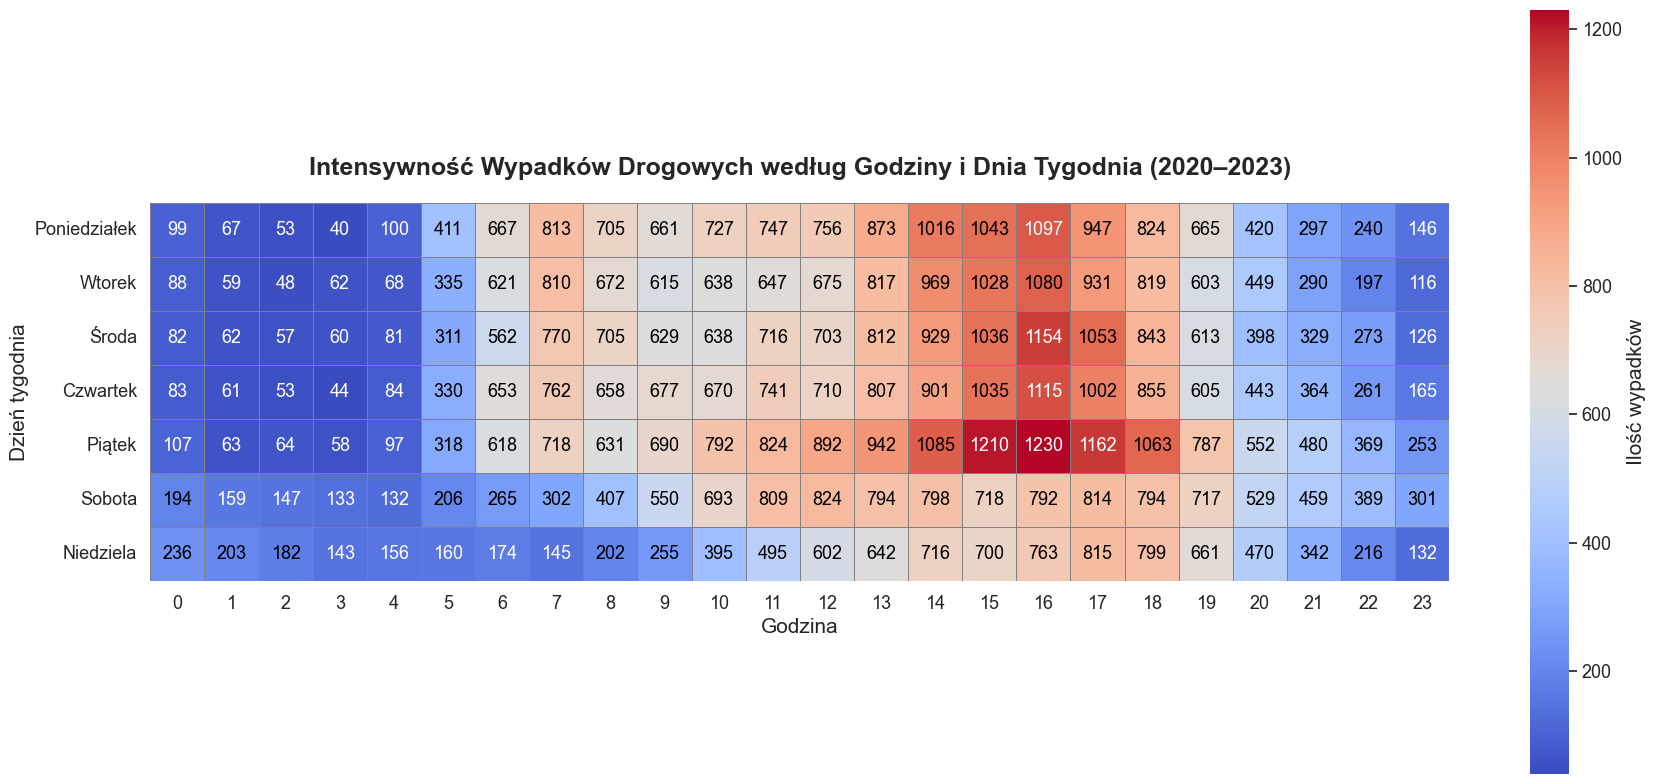

In [6]:
df = pd.read_csv('incidents.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.dayofweek
weekday_names = ['Poniedziałek','Wtorek','Środa','Czwartek','Piątek','Sobota','Niedziela']
df['weekday_name'] = df['weekday'].map(lambda x: weekday_names[x])
heatmap_data = df.pivot_table(
    index='weekday_name',
    columns='hour',
    values='datetime',
    aggfunc='count',
    fill_value=0
)
ordered_days = ['Poniedziałek','Wtorek','Środa','Czwartek','Piątek','Sobota','Niedziela']
heatmap_data = heatmap_data.loc[ordered_days]
plt.figure(figsize=(18, 8))
sns.set_theme(style="white")

ax = sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Ilość wypadków'},
    square=True,
    annot=True,
    fmt='d',
    annot_kws={"fontsize": 13}
)

cmap = plt.get_cmap("coolwarm")
norm = plt.Normalize(vmin=heatmap_data.values.min(), vmax=heatmap_data.values.max())

for text in ax.texts:
    val = float(text.get_text())
    r, g, b, _ = cmap(norm(val))
    brightness = 0.299*r + 0.587*g + 0.114*b
    text.set_color('black' if brightness > 0.5 else 'white')

ax.set_title("Intensywność Wypadków Drogowych według Godziny i Dnia Tygodnia (2020–2023)", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Godzina", fontsize=15)
ax.set_ylabel("Dzień tygodnia", fontsize=15)

ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_size(15)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.savefig('heatmap_wypadki.png')
plt.show()

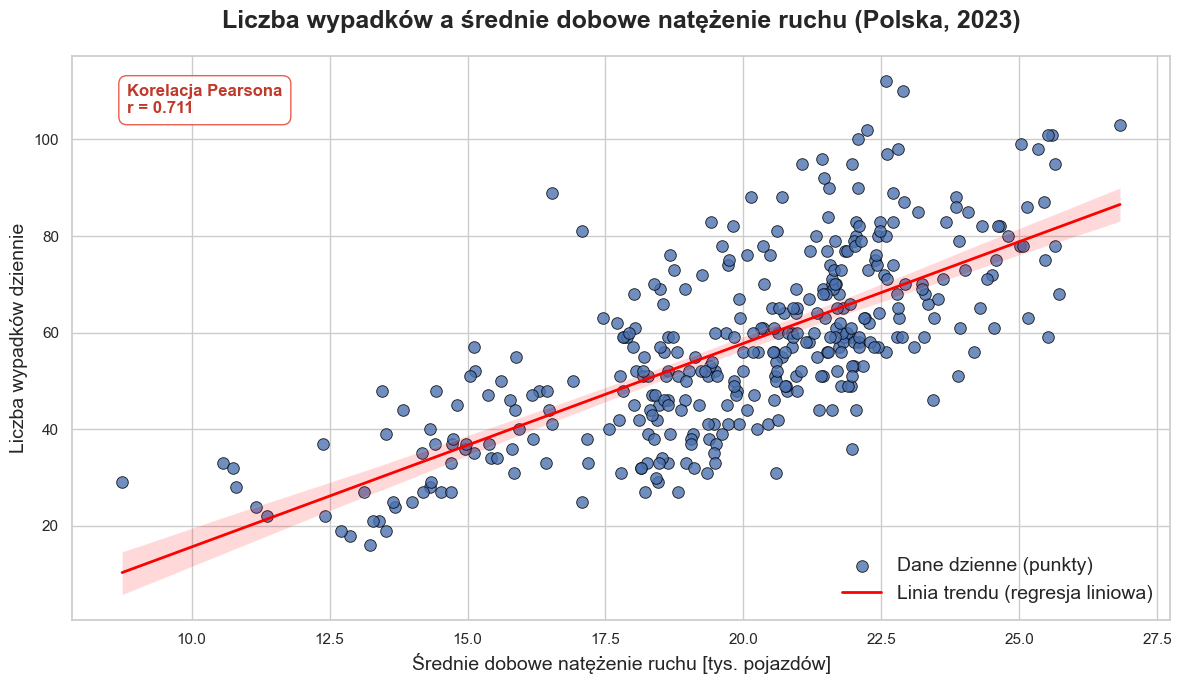

In [8]:
df_acc = pd.read_csv("incidents.csv", low_memory=False)
df_traffic = pd.read_csv("DANE2023.csv", sep=";", low_memory=False)
df_acc['datetime'] = pd.to_datetime(df_acc['datetime'], format='ISO8601')
df_acc_2023 = df_acc[df_acc["datetime"].dt.year == 2023].copy()
acc_per_day = (
    df_acc_2023
    .groupby(df_acc_2023["datetime"].dt.date)
    .size()
    .reset_index(name="accidents")
)
acc_per_day["date"] = pd.to_datetime(acc_per_day["datetime"])
df_traffic["DATA"] = pd.to_datetime(df_traffic["DATA"], format="ISO8601")
traffic_per_day = (
    df_traffic
    .groupby("DATA")["SDRD"]
    .mean()
    .reset_index(name="traffic_mean")
)
traffic_per_day.rename(columns={"DATA": "date"}, inplace=True)
df = acc_per_day.merge(traffic_per_day, on="date", how="inner")
df["traffic_mean_k"] = df["traffic_mean"] / 1000
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=df,
    x="traffic_mean_k",
    y="accidents",
    s=70,
    alpha=0.8,
    edgecolor="black",
    label="Dane dzienne (punkty)"
)

reg_plot = sns.regplot(
    data=df,
    x="traffic_mean_k",
    y="accidents",
    scatter=False,
    color="red",
    line_kws={"linewidth": 2}
)

r_value = df["traffic_mean_k"].corr(df["accidents"])
insight_text = f"Korelacja Pearsona\nr = {r_value:.3f}"
ax = plt.gca()
plt.text(0.05, 0.95, insight_text, 
         transform=ax.transAxes, 
         fontsize=12, fontweight='bold',
         ha='left', va='top', color='#c0392b',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#e74c3c'))

reg_plot.get_lines()[0].set_label("Linia trendu (regresja liniowa)")
plt.legend(fontsize=14)
plt.xlabel("Średnie dobowe natężenie ruchu [tys. pojazdów]", fontsize=14)
plt.ylabel('Liczba wypadków dziennie', fontsize=14)
plt.title('Liczba wypadków a średnie dobowe natężenie ruchu (Polska, 2023)', fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('scatter_wypadki_legenda.png', bbox_inches='tight')
plt.show()

In [ ]:
df = pd.read_excel("fatalities_2010-24_public_0.xlsx")
df.columns = df.columns.astype(str)
tlumaczenia = {
    "France": "Francja",
    "Germany": "Niemcy",
    "Italy": "Włochy",
    "Poland": "Polska",
    "Spain": "Hiszpania",
    "Romania": "Rumunia",
    "Greece": "Grecja",
    "Portugal": "Portugalia",
    "Hungary": "Węgry",
    "Netherlands": "Holandia"

}
df_top10 = df.nlargest(10, "2024").sort_values("2024", ascending=True)
df_top10["Country"] = df_top10["Country"].replace(tlumaczenia)
cmap = sns.color_palette("Wistia", as_cmap=True)
norm = plt.Normalize(df_top10["2024"].min(), df_top10["2024"].max())
colors = cmap(norm(df_top10["2024"]))
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(df_top10["Country"], df_top10["2024"], color=colors)

for bar, value in zip(bars, df_top10["2024"]):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2 - 0.05,
            f"{int(value)}", ha='center', va='center', color='black', fontsize=20)

ax.set_xlabel("liczba ofiar śmiertelnych wypadków drogowych", fontsize = 15)
ax.set_title("Ofiary śmiertelne wypadków drogowych w 10 wiodących krajach europejskich* (2024)" , fontsize=18, fontweight='bold', pad=20)
ax.tick_params(axis='y', labelsize=15)

ax.text(0, -0.1, '* Strefa Statystyczna UE/EFTA',
        transform=ax.transAxes, fontsize=10, verticalalignment='center')

plt.tight_layout()
plt.savefig("barh_wypadki.png", bbox_inches='tight')
plt.show()

In [ ]:
import folium
df = pd.read_csv('who_traffic_death_rate.csv')
url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(url)
world = world.rename(columns={'ADM0_A3': 'iso_a3'})
world.loc[world['iso_a3'] == 'SDS', 'iso_a3'] = 'SSD'
world.loc[world['ADMIN'] == 'Somaliland', 'iso_a3'] = 'SOM'
world_merged = world.merge(df, left_on='iso_a3', right_on='SpatialDimValueCode', how='left')
world_merged['Tooltip_Value'] = world_merged['Value'].apply(lambda x: f"{x}" if pd.notnull(x) else "No Data")
world_merged['Location_Name'] = world_merged['Location'].fillna(world_merged['ADMIN'])
m = folium.Map(location=[20, 0], zoom_start=2)

choropleth = folium.Choropleth(
    geo_data=world_merged,
    name='Road Traffic Deaths',
    data=world_merged,
    columns=['iso_a3', 'Value'],
    key_on='feature.properties.iso_a3',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Śmiertelne wypadki samochodowe (na 100tys. osób)',
    nan_fill_color='lightgray',
    nan_fill_opacity=0.4
)
choropleth.add_to(m)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['Location_Name', 'Tooltip_Value'],
        aliases=['Country:', 'Death Rate:'],
        style=("background-color: white; color: #333333; font-family: arial; font-size: 12px; padding: 10px;")
    )
)

m.save('choropleth_who_death_rate.html')

In [ ]:
from folium.plugins import MarkerCluster
df = pd.read_csv("incidents.csv",low_memory=False)

df["datetime"] = pd.to_datetime(df["datetime"], format="ISO8601")

df["latitude"] = df["latitude"].astype(str).str.replace(",", ".", regex=False).astype(float)
df["longitude"] = df["longitude"].astype(str).str.replace(",", ".", regex=False).astype(float)

df = df[df["datetime"].dt.year == 2023]
df = df.dropna(subset=["latitude", "longitude"])
center_lat = df["latitude"].mean()
center_lon = df["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6,
    tiles="OpenStreetMap"
)

marker_cluster = MarkerCluster().add_to(m)

for _, r in df.iterrows():
    popup = f"""
    <b>Data:</b> {r['datetime']}<br>
    <b>Szerokość:</b> {r['latitude']:.5f}<br>
    <b>Długość:</b> {r['longitude']:.5f}<br>
    """
    folium.CircleMarker(
        location=[r["latitude"], r["longitude"]],
        radius=3,
        fill=True,
        fill_opacity=0.7,
        color="red",
        popup=popup
    ).add_to(marker_cluster)

m.save("wypadki_2023_markercluster.html")
print("Saved wypadki_2023_markercluster.html")

In [ ]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
df = pd.read_csv('incidents.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')
cols = ['road_type', 'surface_condition', 'incident_type']
df_2022 = df[df["datetime"].dt.year == 2022].dropna(subset=cols).copy()
top_6 = df_2022['incident_type'].value_counts().nlargest(6).index
df_2022['incident_type'] = df_2022['incident_type'].apply(lambda x: x if x in top_6 else 'POZOSTAŁE')
df_2022['n1'] = df_2022['road_type'] + " "
df_2022['n2'] = df_2022['surface_condition'] + "  "
df_2022['n3'] = df_2022['incident_type'] + "   "
unique_n1 = df_2022['n1'].unique()
unique_n2 = df_2022['n2'].unique()
palette = px.colors.qualitative.Prism + px.colors.qualitative.Safe
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(list(unique_n1) + list(unique_n2))}
nodes = list(df_2022['n1'].unique()) + list(df_2022['n2'].unique()) + list(df_2022['n3'].unique())
mapping = {name: i for i, name in enumerate(nodes)}

sources, targets, values, link_colors = [], [], [], []
res1 = df_2022.groupby(['n1', 'n2']).size().reset_index(name='count')
for _, row in res1.iterrows():
    sources.append(mapping[row['n1']])
    targets.append(mapping[row['n2']])
    values.append(row['count'])
    c = color_map[row['n1']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))
res2 = df_2022.groupby(['n2', 'n3']).size().reset_index(name='count')
for _, row in res2.iterrows():
    sources.append(mapping[row['n2']])
    targets.append(mapping[row['n3']])
    values.append(row['count'])
    c = color_map[row['n2']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))

fig = go.Figure(go.Sankey(
    arrangement = "snap",
    node = dict(
        pad = 20, thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = [n.strip().upper() for n in nodes],
        color = "royalblue"
    ),
    link = dict(source = sources, target = targets, value = values, color = link_colors)
))

fig.update_layout(
    title={
        'text': "<b>ANALIZA PRZYCZYNOWOŚCI WYPADKÓW DROGOWYCH W POLSCE (2022)</b><br><sup>Rodzaj drogi → Warunki nawierzchni → Typ zdarzenia (Top 6 + Pozostałe)</sup>",
        'y': 0.95,
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}
    },
    font=dict(size=12, family="Arial"),
    autosize=True,
    margin=dict(l=50, r=50, t=100, b=50),
    paper_bgcolor="white"
)

fig.write_html("analiza_wypadkow_2022.html", include_plotlyjs='cdn')

fig.show()

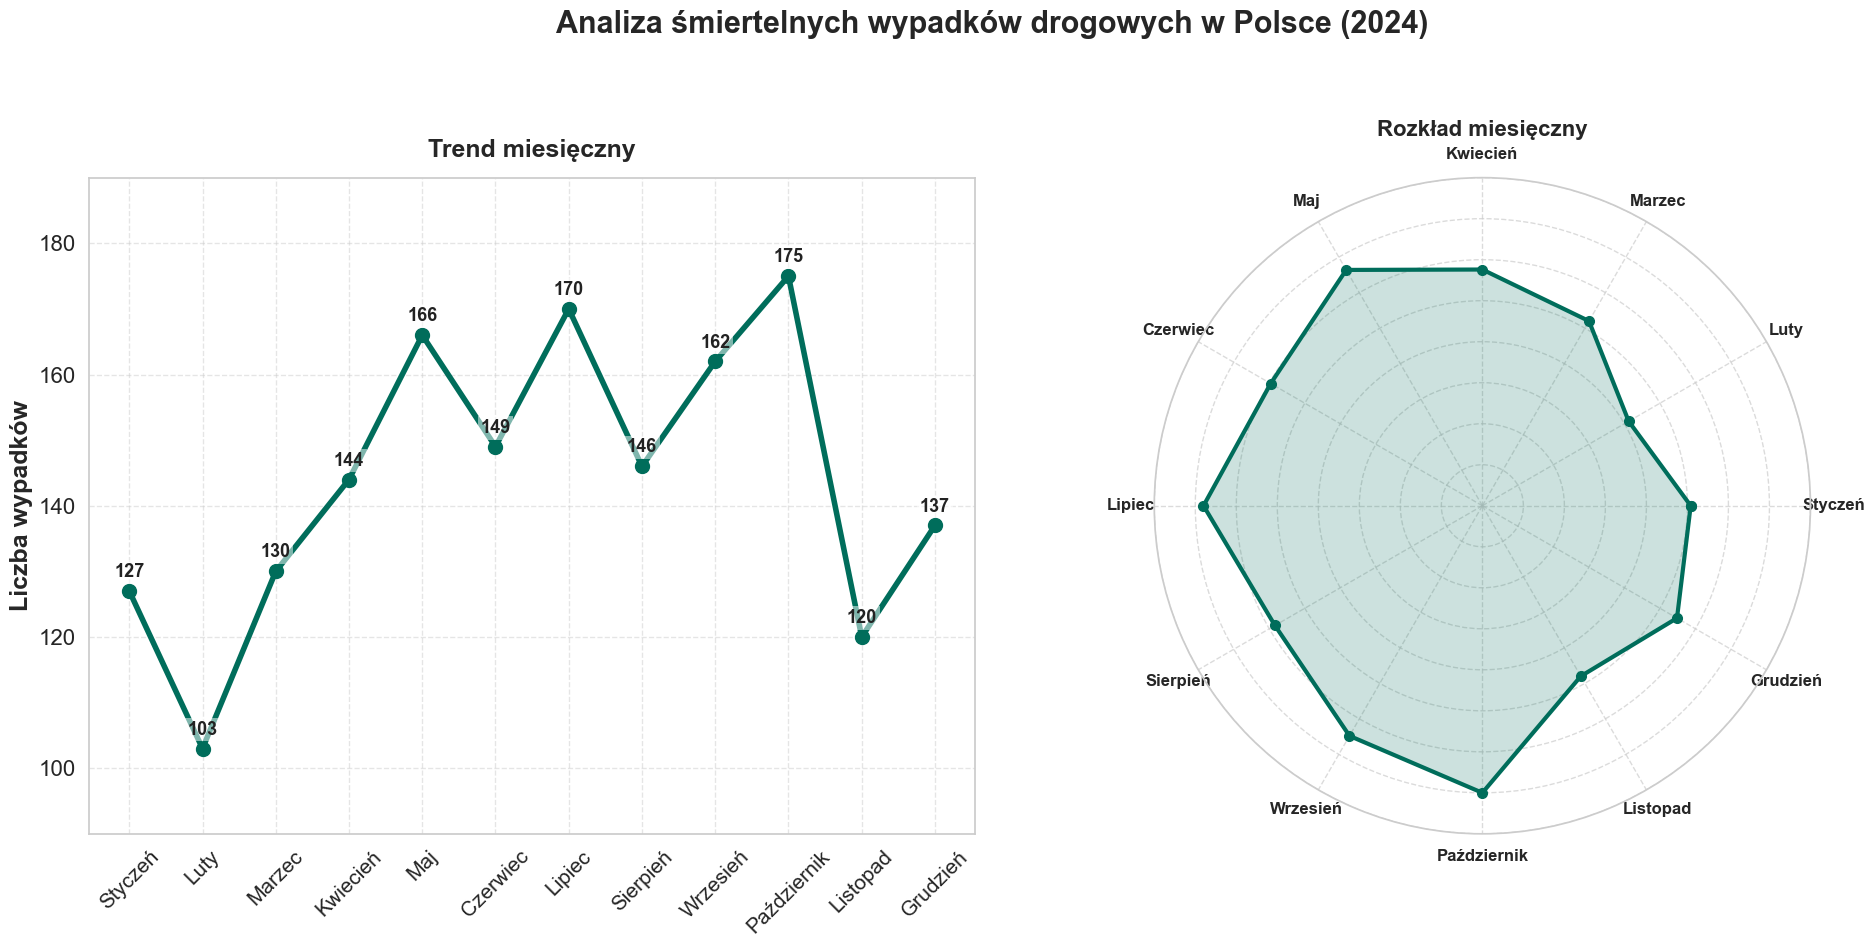

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Źródło danych https://mubi.pl/poradniki/wypadki-ze-skutkiem-smiertelnym-w-polsce-w-2024-roku/
dane = {
    'Miesiąc': [
        'Styczeń', 'Luty', 'Marzec', 'Kwiecień', 'Maj', 'Czerwiec',
        'Lipiec', 'Sierpień', 'Wrzesień', 'Październik', 'Listopad', 'Grudzień'
    ],
    'Liczba wypadków': [
        127, 103, 130, 144, 166, 149, 
        170, 146, 162, 175, 120, 137
    ]
}
df = pd.DataFrame(dane)

labels = df['Miesiąc'].tolist()
stats = df['Liczba wypadków'].tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
stats_closed = stats + [stats[0]]
angles_closed = angles + [angles[0]]


fig = plt.figure(figsize=(20, 9), facecolor='white')
ax1 = fig.add_subplot(121)
ax1.plot(df['Miesiąc'], df['Liczba wypadków'], color='#006d5b', linewidth=4, marker='o', markersize=10)

ax1.set_title('Trend miesięczny', fontsize=18, fontweight='bold', pad=15)
ax1.set_ylabel('Liczba wypadków', fontsize=18, fontweight='bold')
ax1.set_ylim(90, 190)
ax1.tick_params(axis='both', labelsize=16) 
plt.setp(ax1.get_xticklabels(), rotation=45,fontsize=15)
ax1.grid(True, linestyle='--', alpha=0.5)


for i, txt in enumerate(stats):
    ax1.annotate(txt, 
                 (df['Miesiąc'][i], stats[i]),
                 xytext=(0, 10),    
                 textcoords='offset points',   
                 ha='center', 
                 fontsize=13, 
                 fontweight='bold', 
                 color='#222222',
                 bbox=dict(facecolor='white', edgecolor='none', alpha=0.5, pad=2))


ax2 = fig.add_subplot(122, projection='polar')
ax2.plot(angles_closed, stats_closed, color='#006d5b', linewidth=3, marker='o', markersize=7)
ax2.fill(angles_closed, stats_closed, color='#006d5b', alpha=0.2)
ax2.set_title('Rozkład miesięczny', fontsize=16, fontweight='bold', pad=30)
ax2.set_xticks(angles)
ax2.set_xticklabels(labels, fontsize=12, fontweight='bold')
ax2.set_yticklabels([]) 
ax2.set_ylim(0, 200)
ax2.grid(True, linestyle='--', alpha=0.7)


plt.suptitle('Analiza śmiertelnych wypadków drogowych w Polsce (2024)', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

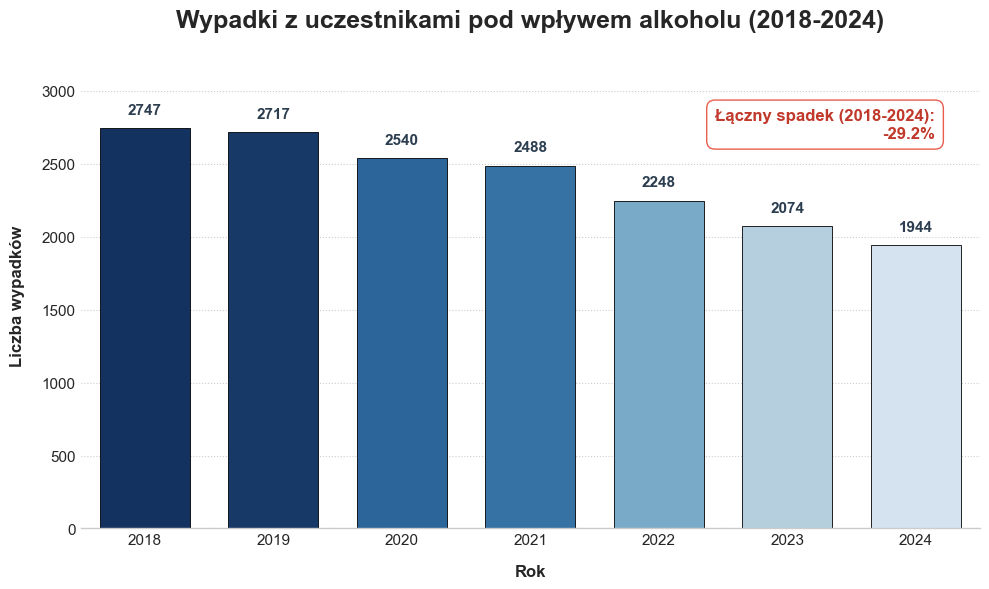

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
# zrodlo danych: https://obserwatoriumbrd.pl/wp-content/uploads/2024/04/Wypadki-z-uczestnikami-pod-wplywem-alkoholu-w-Polsce-w-latach-2018-2023.pdf

dane = {
    'Rok': [2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Wypadki': [2747, 2717, 2540, 2488, 2248, 2074, 1944]
}
df = pd.DataFrame(dane)

plt.figure(figsize=(10, 6))
plt.title('Wypadki z uczestnikami pod wpływem alkoholu (2018-2024)', 
          fontsize=18, fontweight='bold', pad=25)

norm = mcolors.Normalize(vmin=df['Wypadki'].min() * 0.9, vmax=df['Wypadki'].max())
colors = [cm.Blues(norm(value)) for value in df['Wypadki']]

ax = sns.barplot(
    data=df, x='Rok', y='Wypadki', 
    hue='Rok', palette=colors, legend=False,
    edgecolor='black', linewidth=0.6, width=0.7
)

for container in ax.containers:
    ax.bar_label(
        container, 
        padding=8, 
        fontsize=11, 
        fontweight='bold', 
        color='#2c3e50'
    )

sns.despine(left=True)
ax.yaxis.grid(True, color='gray', linestyle=':', alpha=0.4)
ax.set_axisbelow(True)

plt.xlabel('Rok', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('Liczba wypadków', fontsize=12, fontweight='bold', labelpad=12)
plt.tick_params(axis='both', labelsize=11)
plt.ylim(0, 3200)

procent = round((df['Wypadki'].iloc[-1] - df['Wypadki'].iloc[0]) / df['Wypadki'].iloc[0] * 100, 1)
insight_text = f"Łączny spadek (2018-2024):\n{procent}%"

plt.text(0.95, 0.90, insight_text, 
         transform=ax.transAxes, 
         fontsize=12, fontweight='bold',
         ha='right', va='top', color='#c0392b',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#e74c3c'))

plt.tight_layout()
plt.savefig('wypadki_alkohol_custom_blue.png')
plt.show()